# Intraday Volatility Forecasting

## Objective

Most intraday research attempts to predict future returns.

This notebook takes a different approach:

Instead of predicting direction, we attempt to predict future volatility.

---

## Why Volatility Matters

Volatility is one of the most important quantities in financial markets.

It influences:

- Risk management
- Position sizing
- Stop-loss placement
- Options pricing
- Strategy selection

If future volatility can be forecast, trading decisions can be improved even when future returns remain unpredictable.

---

## Research Question

Can information available at time *t* predict realized volatility over the next 15 minutes?

---

## Hypothesis

Volatility is not completely random.

Two well-known market phenomena may create predictability:

### 1. Volatility Clustering

High volatility tends to be followed by high volatility.

Low volatility tends to be followed by low volatility.

Example:

High Volatility
      ↓
High Volatility

Low Volatility
      ↓
Low Volatility

### 2. Intraday Seasonality

Volatility changes systematically throughout the trading day.

Typically:

Open → High Volatility

Midday → Low Volatility

Close → High Volatility

---

## Dataset

- Instrument: NIFTY 50
- Frequency: 1 Minute
- Period: 2015–2025

## Target Variable

Future 15-Minute Realized Volatility

Measured using the standard deviation of returns from:

t + 1

to

t + 15 minutes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../NIFTY_50_minute.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y %H:%M"
)

df = df.set_index("date")

# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]




# Feature Engineering

The objective is to construct variables that may contain information about future volatility.

Features are designed to capture:

- Recent volatility
- Recent momentum
- Recent price range
- Intraday timing effects

These variables will later be evaluated individually and collectively.

In [2]:
df["ret"] = df["close"].pct_change()

df["future_vol_15m"] = (
    df["ret"]
    .rolling(15)
    .std()
    .shift(-15)
)

In [3]:
df["vol_5m"] = (
    df["ret"]
    .rolling(5)
    .std()
)

df["vol_10m"] = (
    df["ret"]
    .rolling(10)
    .std()
)

df["vol_20m"] = (
    df["ret"]
    .rolling(20)
    .std()
)

In [4]:
df["ret_5m"] = (
    df["close"]
    .pct_change(5)
)

df["ret_10m"] = (
    df["close"]
    .pct_change(10)
)

df["range_5m"] = (
    df["high"]
    .rolling(5)
    .max()
    -
    df["low"]
    .rolling(5)
    .min()
) / df["close"]

In [5]:
df["vol_ratio"] = (
    df["vol_5m"]
    /
    df["vol_20m"]
)

df["vol_ratio"] = (
    df["vol_ratio"]
    .replace([np.inf, -np.inf], np.nan)
)

# Individual Feature Analysis

Before building a forecasting model, each feature is examined independently.

The goal is to determine:

Which variables exhibit the strongest relationship with future volatility?

Features with higher correlation may contain more predictive information.

In [6]:
features = [
    "vol_5m",
    "vol_10m",
    "vol_20m",
    "ret_5m",
    "ret_10m",
    "range_5m",
    "vol_ratio"
]

for col in features:

    corr = (
        df[col]
        .corr(
            df["future_vol_15m"]
        )
    )

    print(
        col,
        round(corr, 3)
    )

vol_5m 0.283
vol_10m 0.315
vol_20m 0.343
ret_5m -0.022
ret_10m -0.025
range_5m 0.345
vol_ratio -0.017


# Volatility Clustering Study

## Concept

One of the most widely documented properties of financial markets is volatility clustering.

The hypothesis is:

High Current Volatility -> High Future Volatility

Low Current Volatility -> LowFuture Volatility


To test this idea, observations are grouped into volatility buckets and future volatility is measured for each bucket.

In [7]:
df["vol_bucket"] = pd.qcut(
    df["vol_10m"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

bucket_stats = (
    df.groupby(
        "vol_bucket"
    )["future_vol_15m"]
    .mean()
)

print(bucket_stats)

vol_bucket
Very Low     0.000205
Low          0.000261
Medium       0.000308
High         0.000370
Very High    0.000559
Name: future_vol_15m, dtype: float64


In [9]:
import plotly.express as px

bucket_df = (
    bucket_stats
    .reset_index()
)

fig = px.bar(
    bucket_df,
    x="vol_bucket",
    y="future_vol_15m",
    title="Current Volatility vs Future 15-Minute Volatility"
)

fig.show()

In [11]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

os.makedirs(
    "plots",
    exist_ok=True
)

print("Folders created")

bucket_stats.to_csv(
    "results/volatility_clustering.csv"
)

Folders created


# Intraday Seasonality Study

Financial markets exhibit recurring intraday patterns.

Volatility is often elevated:

- Near the open
- Near the close

and reduced during midday trading.

This section measures the relationship between time-of-day and future volatility.

In [12]:
df["minute_of_day"] = (
    df.index.hour * 60 +
    df.index.minute
)

print(
    df["minute_of_day"]
      .corr(df["future_vol_15m"])
)

0.13964179732401782


In [13]:
df["tod_bucket"] = pd.qcut(
    df["minute_of_day"],
    q=5
)

print(
    df.groupby("tod_bucket")["future_vol_15m"]
      .mean()
)

tod_bucket
(554.999, 629.0]    0.000362
(629.0, 704.0]      0.000264
(704.0, 779.0]      0.000260
(779.0, 854.0]      0.000305
(854.0, 929.0]      0.000511
Name: future_vol_15m, dtype: float64


In [14]:
model_df = df[
    [
        "range_5m",
        "vol_20m",
        "vol_10m",
        "vol_5m",
        "minute_of_day",
        "future_vol_15m"
    ]
].dropna()

In [15]:
split = int(
    len(model_df) * 0.8
)

train = model_df.iloc[:split]
test = model_df.iloc[split:]

# Machine Learning Model

## Why Random Forest?

Relationships between volatility and market variables are often non-linear.

Random Forest models can:

- Capture non-linear interactions
- Handle complex relationships
- Reduce overfitting through averaging

The model is trained using historical observations and evaluated on unseen data.

In [16]:
from sklearn.ensemble import RandomForestRegressor

X_train = train.drop(
    columns=["future_vol_15m"]
)

y_train = train["future_vol_15m"]

X_test = test.drop(
    columns=["future_vol_15m"]
)

y_test = test["future_vol_15m"]

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [17]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

print(importance)

minute_of_day    0.399385
vol_20m          0.282863
range_5m         0.202108
vol_10m          0.079476
vol_5m           0.036169
dtype: float64


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

pred = model.predict(X_test)

print(
    "R²:",
    round(
        r2_score(
            y_test,
            pred
        ),
        4
    )
)

print(
    "MAE:",
    round(
        mean_absolute_error(
            y_test,
            pred
        ),
        6
    )
)

print(
    "Prediction Correlation:",
    round(
        pd.Series(pred).corr(
            pd.Series(y_test.values)
        ),
        4
    )
)

R²: 0.288
MAE: 0.000106
Prediction Correlation: 0.5955


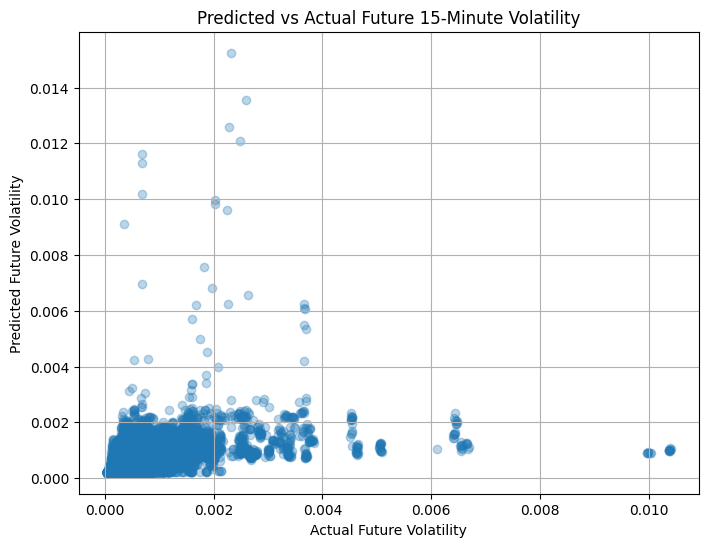

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.3
)

plt.xlabel("Actual Future Volatility")
plt.ylabel("Predicted Future Volatility")

plt.title(
    "Predicted vs Actual Future 15-Minute Volatility"
)

plt.grid(True)

plt.show()

In [20]:
features_no_time = [
    "range_5m",
    "vol_20m",
    "vol_10m",
    "vol_5m"
]

model_df2 = df[
    features_no_time +
    ["future_vol_15m"]
].dropna()

split = int(
    len(model_df2) * 0.8
)

train = model_df2.iloc[:split]
test = model_df2.iloc[split:]

X_train = train[features_no_time]
y_train = train["future_vol_15m"]

X_test = test[features_no_time]
y_test = test["future_vol_15m"]

model2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model2.fit(
    X_train,
    y_train
)

pred2 = model2.predict(X_test)

print(
    "R² (No Time Feature):",
    round(
        r2_score(
            y_test,
            pred2
        ),
        4
    )
)

print(
    "Correlation (No Time Feature):",
    round(
        pd.Series(pred2).corr(
            pd.Series(y_test.values)
        ),
        4
    )
)

R² (No Time Feature): 0.1218
Correlation (No Time Feature): 0.3812


# Horizon Study

## Research Question

Which forecasting horizon is most predictable?

Forecast horizons tested:

- 5 Minutes
- 10 Minutes
- 15 Minutes
- 30 Minutes
- 60 Minutes

---

Very short horizons contain substantial market noise.

Very long horizons may be affected by new information entering the market.

This experiment attempts to identify the optimal forecasting horizon.

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

horizons = [5, 10, 15, 30, 60]

results = []

for h in horizons:

    temp = df.copy()

    temp[f"future_vol_{h}m"] = (
        temp["ret"]
        .rolling(h)
        .std()
        .shift(-h)
    )

    model_df = temp[
        [
            "range_5m",
            "vol_20m",
            "vol_10m",
            "vol_5m",
            "minute_of_day",
            f"future_vol_{h}m"
        ]
    ].dropna()

    split = int(len(model_df) * 0.8)

    train = model_df.iloc[:split]
    test = model_df.iloc[split:]

    X_train = train.drop(
        columns=[f"future_vol_{h}m"]
    )

    y_train = train[f"future_vol_{h}m"]

    X_test = test.drop(
        columns=[f"future_vol_{h}m"]
    )

    y_test = test[f"future_vol_{h}m"]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    results.append({
        "Horizon (min)": h,
        "R²": round(
            r2_score(
                y_test,
                pred
            ),
            3
        ),
        "Correlation": round(
            pd.Series(pred).corr(
                pd.Series(y_test.values)
            ),
            3
        )
    })

horizon_results = pd.DataFrame(results)

print(horizon_results)

   Horizon (min)     R²  Correlation
0              5  0.089        0.516
1             10  0.227        0.572
2             15  0.288        0.595
3             30  0.253        0.574
4             60  0.272        0.576


In [22]:
import os

os.makedirs("results", exist_ok=True)

horizon_results.to_csv(
    "results/horizon_study.csv",
    index=False
)

plt.savefig(
    "plots/horizon_study.png",
    dpi=300,
    bbox_inches="tight"
)

print("Horizon study saved")

Horizon study saved


<Figure size 640x480 with 0 Axes>

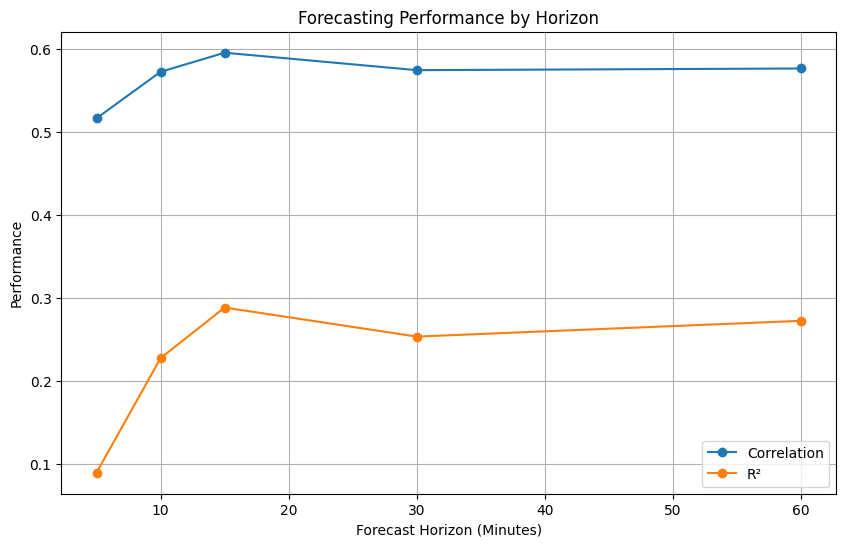

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    horizon_results["Horizon (min)"],
    horizon_results["Correlation"],
    marker="o",
    label="Correlation"
)

plt.plot(
    horizon_results["Horizon (min)"],
    horizon_results["R²"],
    marker="o",
    label="R²"
)

plt.title(
    "Forecasting Performance by Horizon"
)

plt.xlabel(
    "Forecast Horizon (Minutes)"
)

plt.ylabel(
    "Performance"
)

plt.grid(True)

plt.legend()

plt.show()

# Regime Stability Analysis

A useful forecasting model should remain effective across different market environments.

Performance is evaluated separately across:

- 2015–2019
- 2020–2022
- 2023–2025

This helps determine whether the model captures a structural market phenomenon or a temporary historical effect.

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

periods = {
    "2015-2019": ("2015-01-01", "2019-12-31"),
    "2020-2022": ("2020-01-01", "2022-12-31"),
    "2023-2025": ("2023-01-01", df.index.max())
}

results = []

for name, (start, end) in periods.items():

    temp = df.loc[start:end].copy()

    model_df = temp[
        [
            "range_5m",
            "vol_20m",
            "vol_10m",
            "vol_5m",
            "minute_of_day",
            "future_vol_15m"
        ]
    ].dropna()

    split = int(
        len(model_df) * 0.8
    )

    train = model_df.iloc[:split]
    test = model_df.iloc[split:]

    X_train = train.drop(
        columns=["future_vol_15m"]
    )

    y_train = train["future_vol_15m"]

    X_test = test.drop(
        columns=["future_vol_15m"]
    )

    y_test = test["future_vol_15m"]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    results.append({
        "Period": name,
        "R²": round(
            r2_score(
                y_test,
                pred
            ),
            3
        ),
        "Correlation": round(
            pd.Series(pred).corr(
                pd.Series(y_test.values)
            ),
            3
        )
    })

regime_results = pd.DataFrame(
    results
)

print(regime_results)

      Period     R²  Correlation
0  2015-2019  0.283        0.603
1  2020-2022  0.483        0.710
2  2023-2025  0.339        0.588


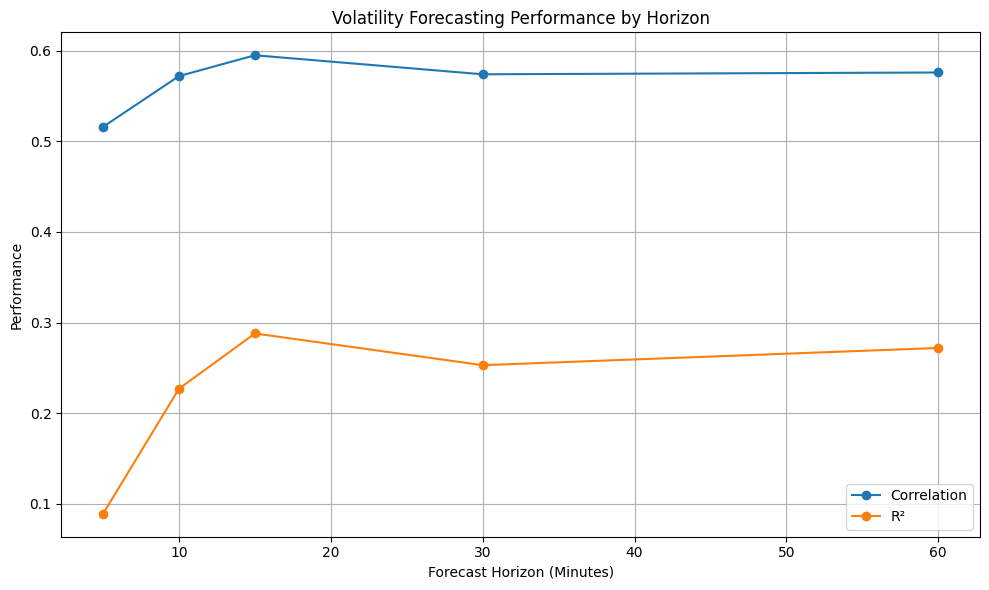

In [30]:
plt.figure(figsize=(10,6))

plt.plot(
    horizon_results["Horizon (min)"],
    horizon_results["Correlation"],
    marker="o",
    label="Correlation"
)

plt.plot(
    horizon_results["Horizon (min)"],
    horizon_results["R²"],
    marker="o",
    label="R²"
)

plt.title(
    "Volatility Forecasting Performance by Horizon"
)

plt.xlabel(
    "Forecast Horizon (Minutes)"
)

plt.ylabel(
    "Performance"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/horizon_study.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

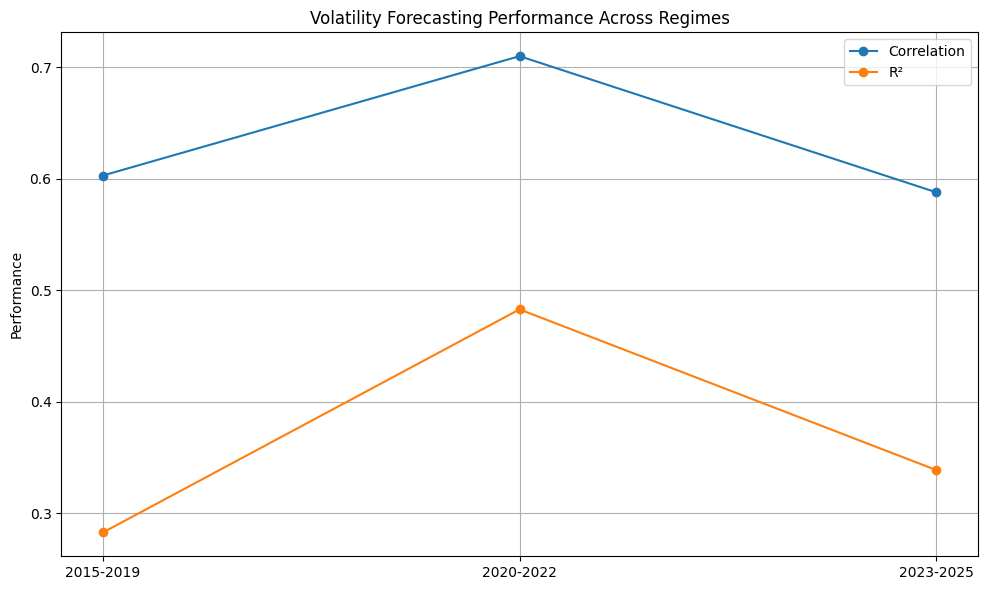

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    regime_results["Period"],
    regime_results["Correlation"],
    marker="o",
    label="Correlation"
)

plt.plot(
    regime_results["Period"],
    regime_results["R²"],
    marker="o",
    label="R²"
)

plt.title(
    "Volatility Forecasting Performance Across Regimes"
)

plt.ylabel(
    "Performance"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/volatility_regime_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
feature_results = []

for name, (start, end) in periods.items():

    temp = df.loc[start:end].copy()

    model_df = temp[
        [
            "range_5m",
            "vol_20m",
            "vol_10m",
            "vol_5m",
            "minute_of_day",
            "future_vol_15m"
        ]
    ].dropna()

    split = int(len(model_df) * 0.8)

    train = model_df.iloc[:split]

    X_train = train.drop(
        columns=["future_vol_15m"]
    )

    y_train = train["future_vol_15m"]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    importance = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    row = {"Period": name}

    for feature, value in importance.items():
        row[feature] = round(value, 3)

    feature_results.append(row)

feature_table = pd.DataFrame(
    feature_results
)

feature_table

,Period,range_5m,vol_20m,vol_10m,vol_5m,minute_of_day
0,2015-2019,0.209,0.180,0.075,0.044,0.492
1,2020-2022,0.130,0.305,0.182,0.047,0.336
2,2023-2025,0.181,0.262,0.061,0.048,0.449


In [28]:
feature_table.to_csv(
    "results/feature_importance_by_regime.csv",
    index=False
)

feature_table

,Period,range_5m,vol_20m,vol_10m,vol_5m,minute_of_day
0,2015-2019,0.209,0.180,0.075,0.044,0.492
1,2020-2022,0.130,0.305,0.182,0.047,0.336
2,2023-2025,0.181,0.262,0.061,0.048,0.449


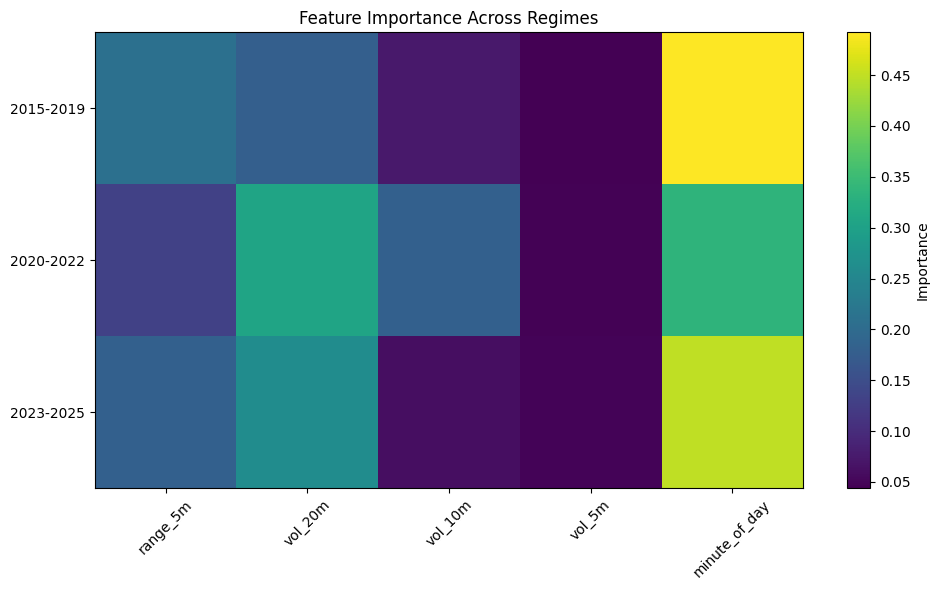

In [29]:
heatmap_df = feature_table.set_index(
    "Period"
)

plt.figure(figsize=(10,6))

plt.imshow(
    heatmap_df,
    aspect="auto"
)

plt.colorbar(
    label="Importance"
)

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

plt.title(
    "Feature Importance Across Regimes"
)

plt.tight_layout()

plt.savefig(
    "plots/feature_importance_by_regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
prediction_data = pd.DataFrame(
    {
        "actual_vol": y_test,
        "predicted_vol": pred
    },
    index=y_test.index
)

prediction_data.head()


prediction_data.to_csv(
    "results/volatility_predictions.csv"
)

In [40]:
feature_df = df[
    [
        "range_5m",
        "vol_20m",
        "vol_10m",
        "vol_5m",
        "minute_of_day",
        "future_vol_15m"
    ]
].dropna()

feature_df.to_csv(
    "results/model_features.csv"
)

# Conclusions

## Research Question

Can current market conditions predict future 15-minute volatility?

---

## Evidence

### Volatility Clustering

Future volatility increased consistently as current volatility increased.

The highest-volatility regime produced approximately 2.7× the future volatility of the lowest-volatility regime.

### Intraday Seasonality

Volatility exhibited a clear U-shaped profile:

High → Low → High

Open and close periods contained the highest future volatility.

### Forecasting Model

Random Forest achieved:

- R² = 0.288
- Correlation = 0.596
- MAE = 0.000106

### Horizon Study

15-minute volatility proved the most predictable forecast horizon.

### Regime Study

Performance remained strong across all periods:

- 2015–2019: Correlation = 0.603
- 2020–2022: Correlation = 0.710
- 2023–2025: Correlation = 0.588

Unlike return-prediction signals, predictive power did not collapse after 2023.

### Feature Importance

The strongest predictors were:

1. Time of Day
2. 20-Minute Volatility
3. 5-Minute Range

---

## Verdict

🟢 Accepted

Future intraday volatility is meaningfully predictable using information available at the current minute.

The strongest sources of predictability are:

- Volatility clustering
- Intraday seasonality
- Recent price range expansion

Unlike many return-based signals, volatility forecasting remained robust across all market regimes.

This suggests volatility predictability is a structural feature of financial markets rather than a temporary historical anomaly.